In [1]:
!pip install scikit-learn statsmodels catboost scipy -q


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import requests
import xml.etree.ElementTree as ET
from scipy import stats
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone
from catboost import CatBoostRegressor
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

In [3]:
def moex_shares(ticker, start, end):
    rows_all, s = [], 0
    while True:
        url = (f"https://iss.moex.com/iss/history/engines/stock/markets/shares"
               f"/boards/TQBR/securities/{ticker}.json?"
               f"from={start}&till={end}&start={s}")
        r = requests.get(url).json()
        rows, cols = r['history']['data'], r['history']['columns']
        if not rows:
            break
        rows_all += rows
        s += len(rows)
    if not rows_all:
        return pd.Series(dtype=float)
    df = pd.DataFrame(rows_all, columns=cols)
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    return df.set_index('TRADEDATE')['CLOSE'].apply(
        pd.to_numeric, errors='coerce').pipe(lambda x: x[x > 0])


def moex_index(start, end):
    rows_all, s = [], 0
    while True:
        url = (f"https://iss.moex.com/iss/history/engines/stock/markets/index"
               f"/boards/SNDX/securities/IMOEX.json?"
               f"from={start}&till={end}&start={s}")
        r = requests.get(url).json()
        rows, cols = r['history']['data'], r['history']['columns']
        if not rows:
            break
        rows_all += rows
        s += len(rows)
    df = pd.DataFrame(rows_all, columns=cols)
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    return df.set_index('TRADEDATE')['CLOSE'].apply(
        pd.to_numeric, errors='coerce').pipe(lambda x: x[x > 0])


def cbr_usd(start, end):
    p1, p2 = start.split('-'), end.split('-')
    d1 = f"{p1[2]}/{p1[1]}/{p1[0]}"
    d2 = f"{p2[2]}/{p2[1]}/{p2[0]}"
    url = (f"https://www.cbr.ru/scripts/XML_dynamic.asp?"
           f"date_req1={d1}&date_req2={d2}&VAL_NM_RQ=R01235")
    root = ET.fromstring(requests.get(url).content)
    recs = [(pd.to_datetime(r.attrib['Date'], dayfirst=True),
             float(r.find('Value').text.replace(',', '.')))
            for r in root.findall('Record')]
    return pd.Series(dict(recs)).sort_index()

In [5]:
START, END = '2023-01-01', '2025-12-31'
TREATED = 'TCSG'
CONTROLS = ['SBER', 'VTBR', 'YDEX', 'MTSS']

data = {}
old = moex_shares('TCSG', START, END)
new = moex_shares('T', START, END)
data['TCSG'] = pd.concat([old, new]).pipe(
    lambda x: x[~x.index.duplicated(keep='last')]).sort_index()
for t in CONTROLS:
    data[t] = moex_shares(t, START, END)
data['IMOEX'] = moex_index(START, END)
data['USD'] = cbr_usd(START, END).reindex(data['IMOEX'].index, method='ffill')

prices = pd.DataFrame(data).dropna()
rets = prices.pct_change().iloc[1:].replace([np.inf, -np.inf], np.nan).dropna()
N_DAYS = len(rets)
print(f"Loaded: {N_DAYS} days")

# ─── Оценка beta_i из реальных данных (OLS: ret_i ~ IMOEX) ────────────────────

imoex_vals = rets['IMOEX'].values
usd_vals = rets['USD'].values

slope_treated, intercept_treated, _, _, _ = stats.linregress(imoex_vals, rets[TREATED].values)
BETA_TREATED = slope_treated
print(f"Beta_{TREATED} = {BETA_TREATED:.4f}")

# Оценка sigma из остатков реальной регрессии (без нелинейности, для масштаба)
resid_real = rets[TREATED].values - (intercept_treated + BETA_TREATED * imoex_vals)
SIGMA = np.std(resid_real)
print(f"Sigma (residual std) = {SIGMA:.5f}")

# ─── Параметры DGP ────────────────────────────────────────────────────────────

# Коэффициент нелинейной функции g(X_t)
# Подбираем c так, чтобы вклад g(X) был ощутимым, но не доминирующим
# g(X_t) = c * (IMOEX_t^2 * sign(IMOEX_t) + 0.5 * |USD/RUB_t| * IMOEX_t)
C_NONLIN = 5.0  # масштабирующий коэффициент нелинейности

# Проверим масштаб g на реальных данных
g_real = C_NONLIN * (imoex_vals**2 * np.sign(imoex_vals) +
                     0.5 * np.abs(usd_vals) * imoex_vals)
print(f"g(X) stats: mean={np.mean(g_real)*100:.4f}%, std={np.std(g_real)*100:.4f}%")
print(f"Ratio std(g)/sigma = {np.std(g_real)/SIGMA:.3f}")

Loaded: 368 days
Beta_TCSG = 0.8018
Sigma (residual std) = 0.01611
g(X) stats: mean=0.0125%, std=0.3298%
Ratio std(g)/sigma = 0.205


In [6]:
def g_function(imoex_t, usd_rub_t, c=C_NONLIN):
    """
    g(X_t) = c * (IMOEX_t^2 * sign(IMOEX_t) + 0.5 * |USD/RUB_t| * IMOEX_t)
    """
    return c * (imoex_t**2 * np.sign(imoex_t) + 0.5 * np.abs(usd_rub_t) * imoex_t)


def generate_data_functional(t_event, tau, params, seed=None):
    """
    Генерирует данные по модели:
    y_it = beta_i * IMOEX_t + g(X_t) + theta * D_it + eps_it
    
    где g(X_t) = c * (IMOEX_t^2 * sign(IMOEX_t) + 0.5 * |USD/RUB_t| * IMOEX_t)
    """
    rng = np.random.default_rng(seed)
    
    T = params['N_DAYS']
    imoex = params['imoex'].copy()
    usd = params['usd'].copy()
    beta = params['beta_treated']
    sigma = params['sigma']
    
    # Индикатор воздействия
    D = (np.arange(T) >= t_event).astype(float)
    
    # Нелинейная функция
    g_vals = g_function(imoex, usd, c=params['c_nonlin'])
    
    # Шум (bootstrap из стандартизированных остатков)
    resid_std = params['resid_std']
    z = rng.choice(resid_std, size=T)
    eps = sigma * z
    
    # Генерация доходности treated
    Y_treated = beta * imoex + g_vals + tau * D + eps
    
    # Собираем DataFrame
    df = params['feat_df'].copy()
    df[params['TREATED']] = Y_treated
    df['day'] = np.arange(T)
    df['post'] = (np.arange(T) >= t_event).astype(int)
    df['D'] = D
    
    return df

In [7]:
# Стандартизированные остатки для bootstrap
resid_standardized = resid_real / SIGMA

feat_df = pd.DataFrame(index=rets.index)
for c in CONTROLS:
    feat_df[c] = rets[c].values
feat_df['IMOEX'] = imoex_vals
feat_df['USD_RUB'] = usd_vals
feat_df['mkt_vol5'] = pd.Series(imoex_vals).rolling(5).std().bfill().values
feat_df['mkt_vol20'] = pd.Series(imoex_vals).rolling(20).std().bfill().values
feat_df['mkt_mom5'] = pd.Series(imoex_vals).rolling(5).mean().bfill().values
feat_df['mkt_mom20'] = pd.Series(imoex_vals).rolling(20).mean().bfill().values
feat_df[TREATED] = rets[TREATED].values

PARAMS = dict(
    N_DAYS=N_DAYS,
    TREATED=TREATED,
    CONTROLS=CONTROLS,
    imoex=imoex_vals.copy(),
    usd=usd_vals.copy(),
    beta_treated=BETA_TREATED,
    sigma=SIGMA,
    c_nonlin=C_NONLIN,
    resid_std=resid_standardized.copy(),
    feat_df=feat_df.copy(),
)

In [9]:
def build_ts(synth_df, params):
    controls = params['CONTROLS']
    ts = pd.DataFrame({
        'ret': synth_df[params['TREATED']].values,
        'D': synth_df['D'].values,
        'post': synth_df['post'].values,
        'day': synth_df['day'].values,
        'IMOEX': synth_df['IMOEX'].values,
        'USD_RUB': synth_df['USD_RUB'].values,
    })
    for c in controls:
        ts[c] = synth_df[c].values
    imoex = synth_df['IMOEX'].values
    ts['mkt_vol5'] = pd.Series(imoex).rolling(5).std().bfill().values
    ts['mkt_vol20'] = pd.Series(imoex).rolling(20).std().bfill().values
    ts['mkt_mom5'] = pd.Series(imoex).rolling(5).mean().bfill().values
    ts['mkt_mom20'] = pd.Series(imoex).rolling(20).mean().bfill().values
    return ts


def build_panel(synth_df, params):
    treated = params['TREATED']
    controls = params['CONTROLS']
    frames = []
    for ticker in [treated] + controls:
        tmp = pd.DataFrame({
            'ticker': ticker,
            'day': synth_df['day'].values,
            'post': synth_df['post'].values,
            'ret': synth_df[ticker].values,
            'IMOEX': synth_df['IMOEX'].values,
            'USD_RUB': synth_df['USD_RUB'].values,
        })
        frames.append(tmp)
    panel = pd.concat(frames, ignore_index=True)
    panel['treated'] = (panel['ticker'] == treated).astype(int)
    panel['did_term'] = panel['treated'] * panel['post']
    return panel


def event_study(ts, est_start, est_end, evt_start, evt_end):
    est = ts[(ts['day'] >= est_start) & (ts['day'] <= est_end)]
    evt = ts[(ts['day'] >= evt_start) & (ts['day'] <= evt_end)]
    if len(est) < 10 or len(evt) == 0:
        return np.nan
    slope, intercept, _, _, _ = stats.linregress(est['IMOEX'].values, est['ret'].values)
    ar = evt['ret'].values - (intercept + slope * evt['IMOEX'].values)
    return ar.sum()


def did_classic(panel):
    mod = smf.ols('ret ~ treated + post + did_term', data=panel).fit()
    return mod.params['did_term']


def dml_estimate(ts, ml_model, controls, n_folds=5, seed=42):
    Y = ts['ret'].values
    D = ts['D'].values.astype(float)
    x_cols = controls + ['IMOEX', 'USD_RUB', 'mkt_vol5', 'mkt_vol20', 'mkt_mom5', 'mkt_mom20']
    X = ts[x_cols].values
    n = len(Y)
    resid_y = np.zeros(n)
    resid_d = np.zeros(n)
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    for train_idx, test_idx in kf.split(X):
        my = clone(ml_model).fit(X[train_idx], Y[train_idx])
        resid_y[test_idx] = Y[test_idx] - my.predict(X[test_idx])
        md = clone(ml_model).fit(X[train_idx], D[train_idx])
        resid_d[test_idx] = D[test_idx] - md.predict(X[test_idx])
    denom = np.dot(resid_d, resid_d)
    theta = np.dot(resid_d, resid_y) / denom if denom > 0 else 0.0
    return theta


def run_all_methods(synth_df, params, est_start, est_end, evt_start, evt_end, rf_base, cb_base):
    controls = params['CONTROLS']
    ts = build_ts(synth_df, params)
    panel = build_panel(synth_df, params)
    results = {}
    results['Event Study'] = event_study(ts, est_start, est_end, evt_start, evt_end)
    results['DiD classic'] = did_classic(panel)
    results['DML + OLS'] = dml_estimate(ts, LinearRegression(), controls)
    results['DML + RF'] = dml_estimate(ts, rf_base, controls)
    results['DML + CatBoost'] = dml_estimate(ts, cb_base, controls)
    return results

In [10]:
T_EVENT = N_DAYS // 2
EST_START = 0
EST_END = T_EVENT - 11
EVT_START = T_EVENT
EVT_END = N_DAYS - 1
N_EVENT_DAYS = EVT_END - EVT_START + 1

THETA_GRID = [0.000, 0.001, 0.003, 0.005, 0.010]
N_SIM = 500

METHOD_NAMES = [
    'Event Study',
    'DiD classic',
    'DML + OLS',
    'DML + RF',
    'DML + CatBoost',
]

rf_base = RandomForestRegressor(
    n_estimators=50, max_depth=4, random_state=42, n_jobs=-1)
cb_base = CatBoostRegressor(
    iterations=100, depth=3, learning_rate=0.1,
    verbose=0, random_seed=42, allow_writing_files=False)

print(f"\nDGP: y_it = {BETA_TREATED:.3f}*IMOEX_t + g(X_t) + theta*D_it + eps_it")
print(f"g(X_t) = {C_NONLIN}*(IMOEX²*sign(IMOEX) + 0.5*|USD/RUB|*IMOEX)")
print(f"T={N_DAYS}, t_event={T_EVENT}, N_EVENT_DAYS={N_EVENT_DAYS}, N_SIM={N_SIM}")

all_mc = {theta: {m: [] for m in METHOD_NAMES} for theta in THETA_GRID}
print(f"\nMC: {N_SIM} x {len(THETA_GRID)} = {N_SIM * len(THETA_GRID)}\n")

total_start = time.time()
for theta_idx, theta in enumerate(THETA_GRID):
    t0 = time.time()
    print(f"[{theta_idx+1}/{len(THETA_GRID)}] theta={theta*100:.1f}% ", end='', flush=True)
    for sim in range(N_SIM):
        seed = sim + 1000 + theta_idx * 10000
        synth_df = generate_data_functional(T_EVENT, theta, PARAMS, seed=seed)
        res = run_all_methods(synth_df, PARAMS,
                              EST_START, EST_END, EVT_START, EVT_END,
                              rf_base, cb_base)
        for m in METHOD_NAMES:
            all_mc[theta][m].append(res.get(m, np.nan))
    print(f"({time.time()-t0:.1f}s)")

print(f"\nTotal: {(time.time()-total_start)/60:.1f} min")


DGP: y_it = 0.802*IMOEX_t + g(X_t) + theta*D_it + eps_it
g(X_t) = 5.0*(IMOEX²*sign(IMOEX) + 0.5*|USD/RUB|*IMOEX)
T=368, t_event=184, N_EVENT_DAYS=184, N_SIM=500

MC: 500 x 5 = 2500

[1/5] theta=0.0% (633.3s)
[2/5] theta=0.1% (601.5s)
[3/5] theta=0.3% (621.6s)
[4/5] theta=0.5% (619.1s)
[5/5] theta=1.0% (614.9s)

Total: 51.5 min


In [11]:
summary_rows = []
for theta in THETA_GRID:
    true_car = theta * N_EVENT_DAYS
    for method in METHOD_NAMES:
        arr = np.array(all_mc[theta][method])
        arr = arr[~np.isnan(arr)]
        if len(arr) == 0:
            continue
        target = true_car if method == 'Event Study' else theta
        mean_est = np.mean(arr)
        std_est = np.std(arr)
        bias = mean_est - target
        rmse = np.sqrt(np.mean((arr - target)**2))
        rejection_rate = np.mean(np.abs(arr / std_est) > 1.96) if std_est > 0 else 0.0
        summary_rows.append({
            'theta': theta, 'method': method, 'target': target,
            'mean': mean_est, 'std': std_est, 'bias': bias,
            'rmse': rmse, 'rejection_rate': rejection_rate,
        })

summary_df = pd.DataFrame(summary_rows)

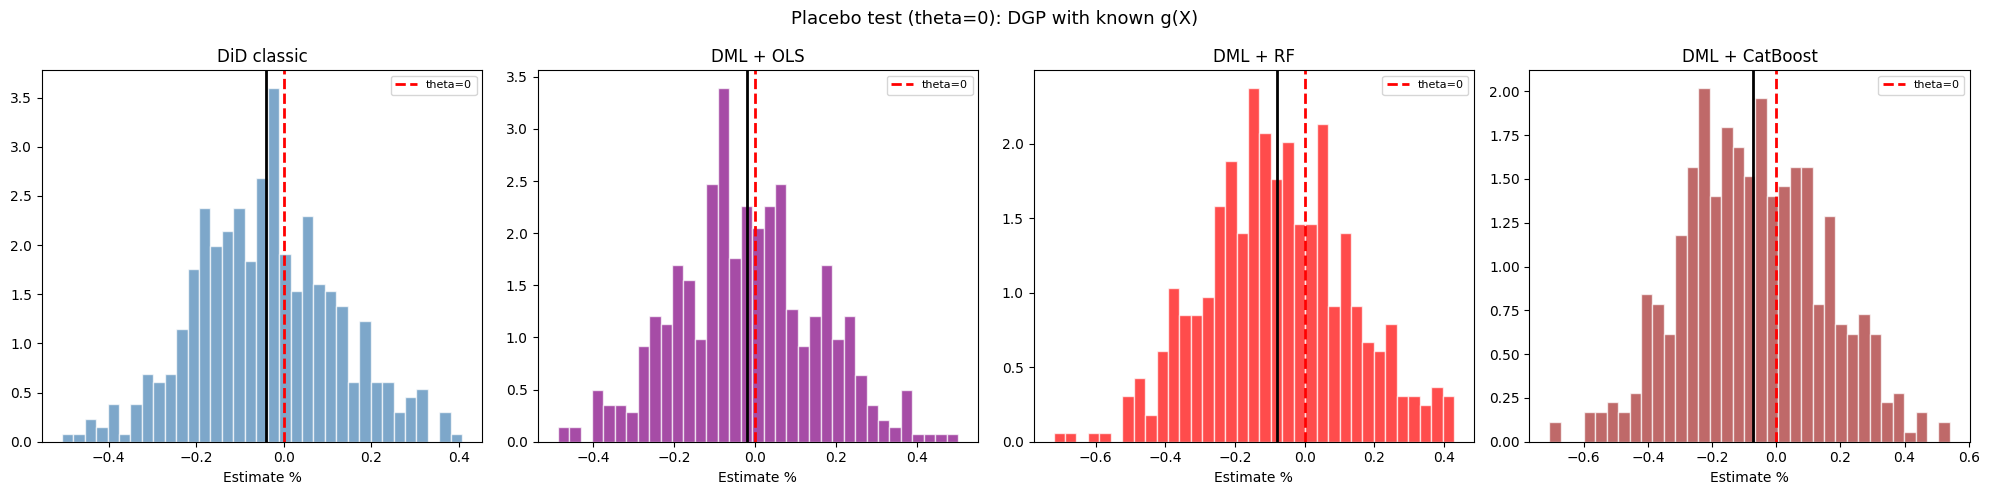

In [12]:
placebo = summary_df[(summary_df['theta'] == 0) & (summary_df['method'] != 'Event Study')]
colors_method = {
    'DiD classic': 'steelblue',
    'DML + OLS': 'purple',
    'DML + RF': 'red',
    'DML + CatBoost': 'brown',
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for idx, (_, row) in enumerate(placebo.iterrows()):
    method = row['method']
    ax = axes[idx]
    arr = np.array(all_mc[0.0][method])
    arr = arr[~np.isnan(arr)]
    ax.hist(arr * 100, bins=35, color=colors_method.get(method, 'gray'),
            alpha=0.7, edgecolor='white', density=True)
    ax.axvline(0, color='red', ls='--', lw=2, label='theta=0')
    ax.axvline(np.mean(arr) * 100, color='black', ls='-', lw=2)
    ax.set_title(f'{method}')
    ax.set_xlabel('Estimate %')
    ax.legend(fontsize=8)
plt.suptitle('Placebo test (theta=0): DGP with known g(X)', fontsize=13)
plt.tight_layout()
plt.show()

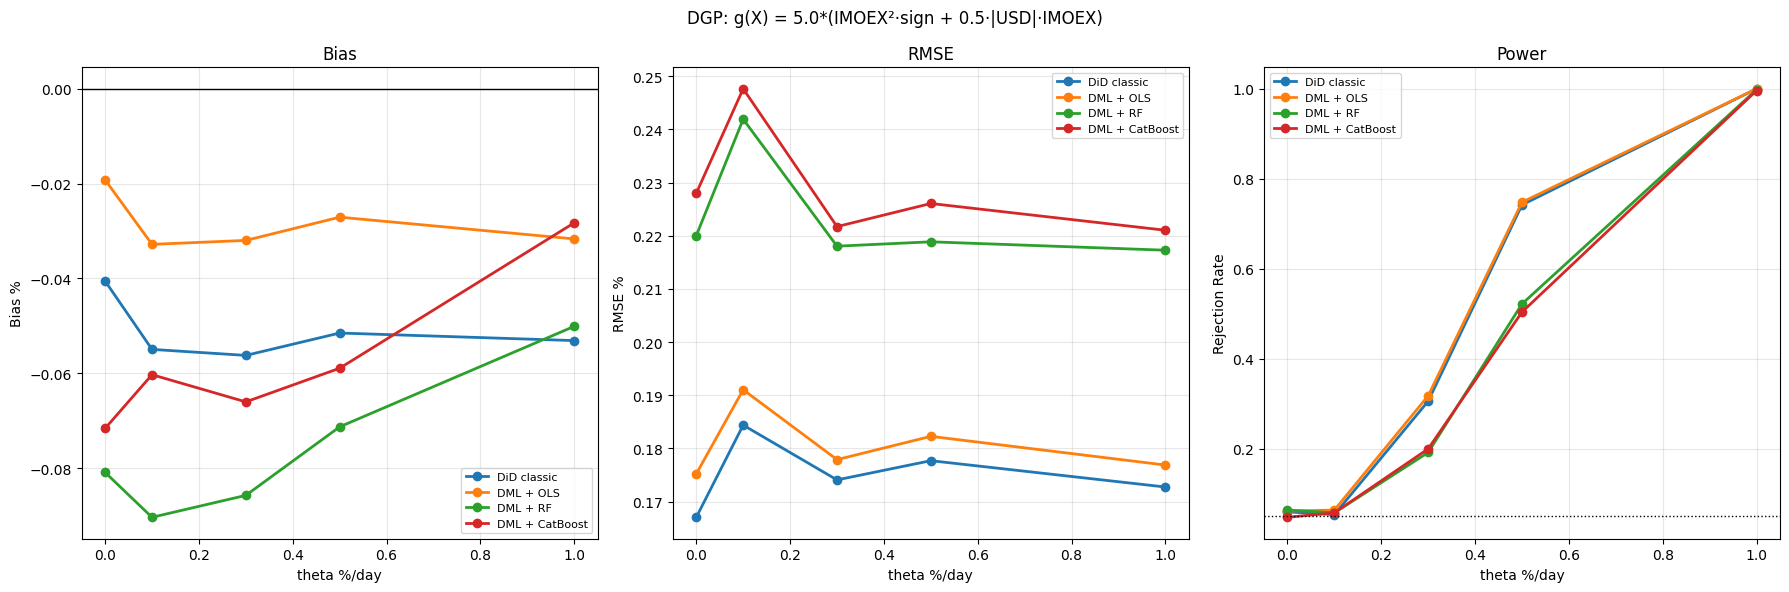

In [13]:
non_es = [m for m in METHOD_NAMES if m != 'Event Study']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ax = axes[0]
for method in non_es:
    sub = summary_df[summary_df['method'] == method]
    ax.plot(sub['theta']*100, sub['bias']*100, 'o-', label=method, lw=2, ms=6)
ax.axhline(0, color='black', lw=1)
ax.set_xlabel('theta %/day')
ax.set_ylabel('Bias %')
ax.set_title('Bias')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
for method in non_es:
    sub = summary_df[summary_df['method'] == method]
    ax.plot(sub['theta']*100, sub['rmse']*100, 'o-', label=method, lw=2, ms=6)
ax.set_xlabel('theta %/day')
ax.set_ylabel('RMSE %')
ax.set_title('RMSE')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[2]
for method in non_es:
    sub = summary_df[summary_df['method'] == method]
    ax.plot(sub['theta']*100, sub['rejection_rate'], 'o-', label=method, lw=2, ms=6)
ax.axhline(0.05, color='black', ls=':', lw=1)
ax.set_xlabel('theta %/day')
ax.set_ylabel('Rejection Rate')
ax.set_title('Power')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle(f'DGP: g(X) = {C_NONLIN}*(IMOEX²·sign + 0.5·|USD|·IMOEX)', fontsize=12)
plt.tight_layout()
plt.show()

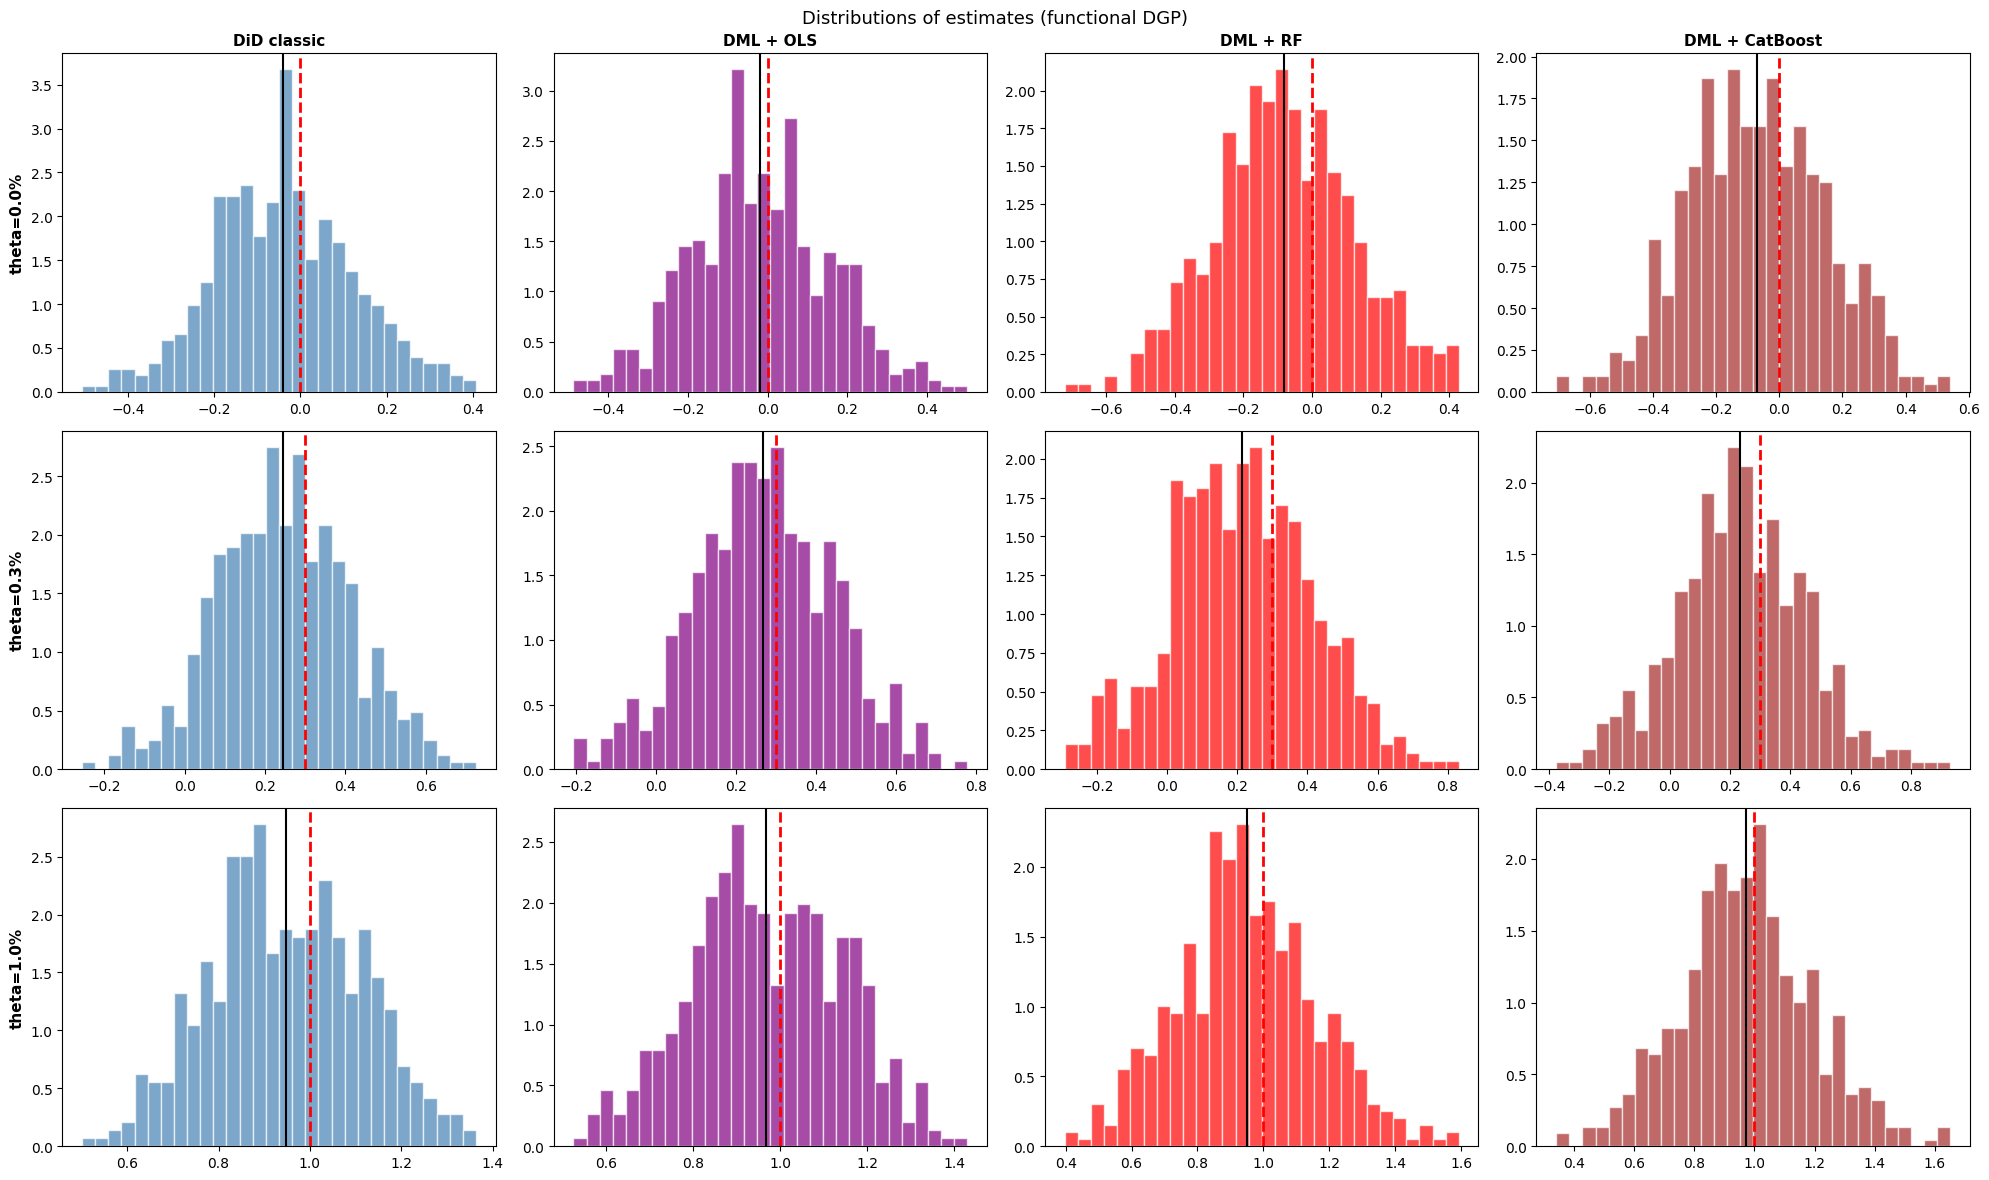

In [14]:
thetas_plot = [0.000, 0.003, 0.010]
methods_plot = ['DiD classic', 'DML + OLS', 'DML + RF', 'DML + CatBoost']

fig, axes = plt.subplots(len(thetas_plot), len(methods_plot),
                         figsize=(5*len(methods_plot), 4*len(thetas_plot)))
for i, theta in enumerate(thetas_plot):
    for j, method in enumerate(methods_plot):
        ax = axes[i, j]
        arr = np.array(all_mc[theta][method])
        arr = arr[~np.isnan(arr)]
        ax.hist(arr*100, bins=30, color=colors_method.get(method, 'gray'),
                alpha=0.7, edgecolor='white', density=True)
        ax.axvline(theta*100, color='red', ls='--', lw=2)
        ax.axvline(np.mean(arr)*100, color='black', ls='-', lw=1.5)
        if i == 0:
            ax.set_title(method, fontsize=11, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f'theta={theta*100:.1f}%', fontsize=11, fontweight='bold')
plt.suptitle('Distributions of estimates (functional DGP)', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
print(f"\n{'='*100}")
print(f"RESULTS: Functional DGP ({N_SIM} simulations)")
print(f"g(X_t) = {C_NONLIN}*(IMOEX_t² * sign(IMOEX_t) + 0.5*|USD/RUB_t|*IMOEX_t)")
print(f"{'='*100}")

for theta in THETA_GRID:
    sub = summary_df[(summary_df['theta'] == theta) &
                     (summary_df['method'] != 'Event Study')]
    print(f"\ntheta = {theta*100:.1f}%/day")
    print(f"{'-'*100}")
    print(f"  {'Method':<22} {'Mean(%)':<12} {'Std(%)':<12} {'Bias(%)':<12} {'RMSE(%)':<12} {'Power':<10}")
    print(f"  {'-'*80}")
    sub_sorted = sub.sort_values('rmse')
    for _, row in sub_sorted.iterrows():
        print(f"  {row['method']:<22} {row['mean']*100:<12.4f} {row['std']*100:<12.4f} "
              f"{row['bias']*100:<12.4f} {row['rmse']*100:<12.4f} {row['rejection_rate']:<10.1%}")

print(f"\nEvent Study (CAR)")
print(f"{'-'*100}")
print(f"  {'theta %/day':<15} {'True CAR%':<15} {'Mean CAR%':<15} {'Bias%':<15} {'RMSE%':<15}")
for theta in THETA_GRID:
    es = summary_df[(summary_df['theta'] == theta) & (summary_df['method'] == 'Event Study')]
    if len(es) > 0:
        row = es.iloc[0]
        print(f"  {theta*100:<15.1f} {row['target']*100:<15.2f} {row['mean']*100:<15.2f} "
              f"{row['bias']*100:<15.2f} {row['rmse']*100:<15.2f}")

print(f"\n{'='*100}")
print(f"Average ranking (theta > 0)")
print(f"{'='*100}")
avg = (summary_df[(summary_df['theta'] > 0) & (summary_df['method'] != 'Event Study')]
       .groupby('method')
       .agg({'rmse': 'mean', 'bias': 'mean', 'std': 'mean', 'rejection_rate': 'mean'})
       .sort_values('rmse'))
for rank, (method, row) in enumerate(avg.iterrows(), 1):
    print(f"  {rank}. {method:<20} RMSE={row['rmse']*100:.4f}% Bias={row['bias']*100:.4f}% "
          f"Std={row['std']*100:.4f}% Power={row['rejection_rate']:.1%}")


RESULTS: Functional DGP (500 simulations)
g(X_t) = 5.0*(IMOEX_t² * sign(IMOEX_t) + 0.5*|USD/RUB_t|*IMOEX_t)

theta = 0.0%/day
----------------------------------------------------------------------------------------------------
  Method                 Mean(%)      Std(%)       Bias(%)      RMSE(%)      Power     
  --------------------------------------------------------------------------------
  DiD classic            -0.0406      0.1620       -0.0406      0.1670       6.0%      
  DML + OLS              -0.0192      0.1741       -0.0192      0.1752       6.2%      
  DML + RF               -0.0809      0.2046       -0.0809      0.2200       6.4%      
  DML + CatBoost         -0.0716      0.2164       -0.0716      0.2280       4.8%      

theta = 0.1%/day
----------------------------------------------------------------------------------------------------
  Method                 Mean(%)      Std(%)       Bias(%)      RMSE(%)      Power     
  ----------------------------------------

In [17]:
rows_out = []
for method in METHOD_NAMES:
    for theta in THETA_GRID:
        sub = summary_df[(summary_df['theta'] == theta) & (summary_df['method'] == method)]
        if len(sub) > 0:
            row = sub.iloc[0]
            rows_out.append({
                'theta': f"{theta*100:.1f}%",
                'method': method,
                'rmse': f"{row['rmse']*100:.4f}",
                'bias': f"{row['bias']*100:.4f}",
                'std': f"{row['std']*100:.4f}",
                'power': f"{row['rejection_rate']*100:.1f}",
            })

df_metrics = pd.DataFrame(rows_out)
df_metrics

,theta,method,rmse,bias,std,power
0,0.0%,Event Study,30.7216,-4.4125,30.4031,5.0
1,0.1%,Event Study,33.5335,-7.0717,32.7794,7.0
2,0.3%,Event Study,31.6735,-7.3626,30.8059,33.0
3,0.5%,Event Study,32.7539,-6.1997,32.1618,76.4
4,1.0%,Event Study,31.5152,-6.8268,30.7669,100.0
5,0.0%,DiD classic,0.1670,-0.0406,0.1620,6.0
6,0.1%,DiD classic,0.1844,-0.0550,0.1760,5.4
7,0.3%,DiD classic,0.1741,-0.0562,0.1647,30.6
8,0.5%,DiD classic,0.1777,-0.0515,0.1700,74.2
9,1.0%,DiD classic,0.1727,-0.0531,0.1644,100.0
